# 1. 라이브러리 불러오기
데이터 탐색과 Feature Engineering 근거를 찾는 용도

그래프 제목은 영어, 해석은 한국어로 작성
 생존율은 표본의 관측 비율이며 인과관계 아님

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from common.utils import train_test_split_by_target
sns.set_theme(style="whitegrid")

# 2. 데이터 불러오기


In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print("train:", train.shape)
display(train.head())
print("test:", test.shape)
display(test.head())

train: (916, 12)


,passengerid,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,NaN,0,0,SC/PARIS 2159,12.8750,NaN,S
1,1,0,3,"Henry, Miss. Delia",female,NaN,0,0,382649,7.7500,NaN,Q
2,2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.0,1,1,12749,93.5000,B69,S
3,3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S
4,4,0,2,"Hold, Mr. Stephen",male,44.0,1,0,26707,26.0000,NaN,S


test: (393, 11)


,passengerid,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,916,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
1,917,2,"Pinsky, Mrs. (Rosa)",female,32.0,0,0,234604,13.0000,NaN,S
2,918,3,"McCarthy, Miss. Catherine Katie""""",female,NaN,0,0,383123,7.7500,NaN,Q
3,919,3,"Franklin, Mr. Charles (Charles Fardon)",male,NaN,0,0,SOTON/O.Q. 3101314,7.2500,NaN,S
4,920,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S


# 3. 데이터 기본 정보 확인


In [3]:
train.info()
print(train.dtypes)
print(train.nunique())
display(train.describe(include="all"))

<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  916 non-null    int64  
 1   survived     916 non-null    int64  
 2   pclass       916 non-null    int64  
 3   name         916 non-null    str    
 4   gender       916 non-null    str    
 5   age          736 non-null    float64
 6   sibsp        916 non-null    int64  
 7   parch        916 non-null    int64  
 8   ticket       916 non-null    str    
 9   fare         916 non-null    float64
 10  cabin        198 non-null    str    
 11  embarked     915 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 86.0 KB
passengerid      int64
survived         int64
pclass           int64
name               str
gender             str
age            float64
sibsp            int64
parch            int64
ticket             str
fare           float64
cabin              str
embark

,passengerid,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
count,916.000000,916.000000,916.000000,916,916,736.000000,916.000000,916.000000,916,916.000000,198,915
unique,NaN,NaN,NaN,915,2,NaN,NaN,NaN,703,NaN,146,3
top,NaN,NaN,NaN,"Connolly, Miss. Kate",male,NaN,NaN,NaN,CA. 2343,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,2,589,NaN,NaN,NaN,7,NaN,4,645
mean,457.500000,0.377729,2.292576,NaN,NaN,29.698370,0.507642,0.361354,NaN,32.402710,NaN,NaN
std,264.570721,0.485084,0.838675,NaN,NaN,14.185627,1.044866,0.828054,NaN,50.506411,NaN,NaN
min,0.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,228.750000,0.000000,2.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,457.500000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.458300,NaN,NaN
75%,686.250000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,30.017700,NaN,NaN


In [4]:
test.info()
print(test.dtypes)
print(test.nunique())
display(test.describe(include="all"))
print("train에만:", set(train.columns) - set(test.columns))
print("test에만:", set(test.columns) - set(train.columns))

<class 'pandas.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  393 non-null    int64  
 1   pclass       393 non-null    int64  
 2   name         393 non-null    str    
 3   gender       393 non-null    str    
 4   age          310 non-null    float64
 5   sibsp        393 non-null    int64  
 6   parch        393 non-null    int64  
 7   ticket       393 non-null    str    
 8   fare         392 non-null    float64
 9   cabin        97 non-null     str    
 10  embarked     392 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 33.9 KB
passengerid      int64
pclass           int64
name               str
gender             str
age            float64
sibsp            int64
parch            int64
ticket             str
fare           float64
cabin              str
embarked           str
dtype: object
passengerid    393
pclass         

,passengerid,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
count,393.000000,393.000000,393,393,310.000000,393.000000,393.000000,393,392.000000,97,392
unique,NaN,NaN,393,2,NaN,NaN,NaN,345,NaN,86,3
top,NaN,NaN,"McGowan, Miss. Anna ""Annie""",male,NaN,NaN,NaN,220845,NaN,F4,S
freq,NaN,NaN,1,254,NaN,NaN,NaN,4,NaN,4,269
mean,1112.000000,2.300254,NaN,NaN,30.315065,0.478372,0.440204,NaN,35.381643,NaN,NaN
std,113.593574,0.836919,NaN,NaN,14.955056,1.035180,0.946051,NaN,54.582654,NaN,NaN
min,916.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,1014.000000,2.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1112.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.281250,NaN,NaN
75%,1210.000000,3.000000,NaN,NaN,40.000000,1.000000,1.000000,NaN,35.125000,NaN,NaN


train에만: {'survived'}
test에만: set()


In [ ]:
# 실제 컬럼명을 확인한 뒤 target을 지정
assert set(train.columns) - set(test.columns) == {"survived"}
target_col = "survived"
train_part, valid_part = train_test_split_by_target(train, target_name=target_col)
eda = train_part.copy()
print("EDA 분석 대상:", eda.shape)
# validation 229행과 test는 아래 관계 분석에 사용하지 않츸

EDA 분석 대상: (687, 12)


# 4. Target 분석
정수 0/1은 사망/생존을 나타내는 이진 분류입니다. 전체 train과 EDA 표본의 비율을 따로 확인합니다.

In [6]:
print("전체 train 클래스 비율")
print(train[target_col].value_counts(normalize=True))
print("EDA 표본 클래스 수와 비율")
print(eda[target_col].value_counts())
print(eda[target_col].value_counts(normalize=True))

전체 train 클래스 비율
survived
0    0.622271
1    0.377729
Name: proportion, dtype: float64
EDA 표본 클래스 수와 비율
survived
0    427
1    260
Name: count, dtype: int64
survived
0    0.621543
1    0.378457
Name: proportion, dtype: float64


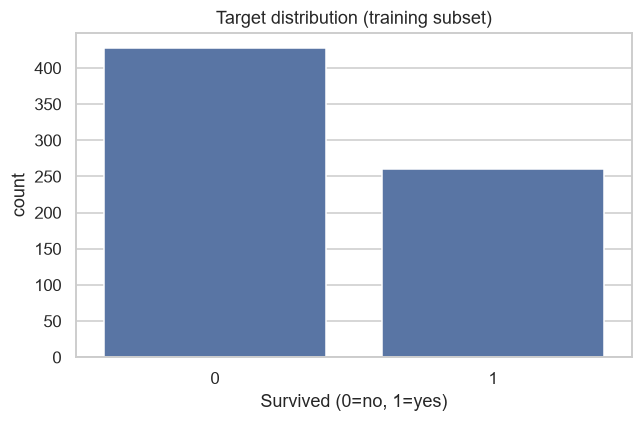

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=eda, x="survived", order=[0, 1])
plt.title("Target distribution (training subset)")
plt.xlabel("Survived (0=no, 1=yes)")
plt.tight_layout()
plt.show()

전체 train의 생존 비율은 약 37.8%, 
사망 비율은 62.2%


# 5. 단일 변수 분석
나이와 운임의 분포를 보고 결측치·긴 꼬리·극단값을 점검합니다. 그래프는 관측된 값만 사용합니다.

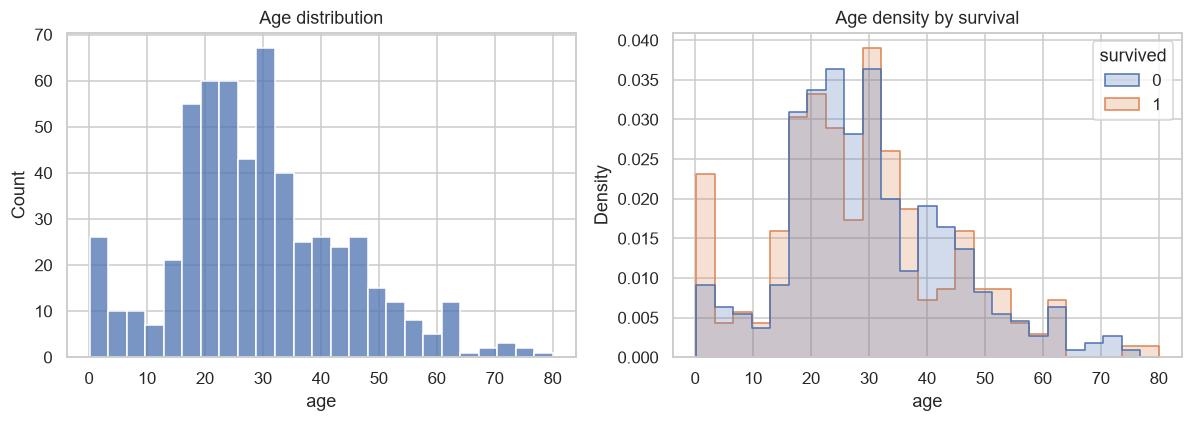

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=eda, x="age", bins=25, ax=axes[0])
axes[0].set_title("Age distribution")
sns.histplot(data=eda, x="age", hue="survived", bins=25, stat="density", common_norm=False, element="step", ax=axes[1])
axes[1].set_title("Age density by survival")
plt.tight_layout()
plt.show()

성인 연령대에 표본이 집중되어 있고 생존/사망 분포가 겹칩니다. 두 클래스의 크기가 달라 오른쪽은 각 클래스 내부 밀도로 비교합니다. 나이 결측 승객은 포함되지 않습니다.

In [9]:
display(eda["fare"].describe(percentiles=[0.5, 0.9, 0.99]))
print("fare skew:", eda["fare"].skew())

count    687.000000
mean      30.963918
std       45.802139
min        0.000000
50%       14.454200
90%       76.466700
99%      230.324412
max      512.329200
Name: fare, dtype: float64

fare skew: 4.193023658895003


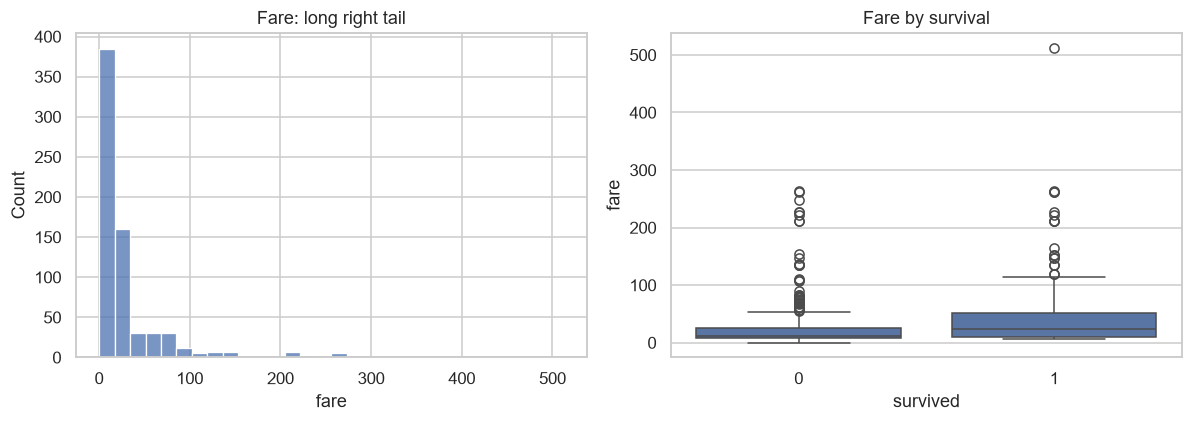

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=eda, x="fare", bins=30, ax=axes[0])
axes[0].set_title("Fare: long right tail")
sns.boxplot(data=eda, x="survived", y="fare", ax=axes[1])
axes[1].set_title("Fare by survival")
plt.tight_layout()
plt.show()

운임은 오른쪽 꼬리가 긴 분포이며 큰 운임 값들이 있습니다. 생존자 운임 중앙값은 사망자보다 높습니다. 극단값은 실제 고가 운임일 수 있으므로 자동 삭제하지 않고 log1p 변환 후보로 검토합니다.

# 6. Target vs Features
성별·객실등급·가족·항구 및 여러 변수의 조합을 봅니다. 생존율 표에는 표본 수도 함께 제시합니다.

In [11]:
display(eda.groupby("gender")[target_col].agg(["size", "mean"]))
display(pd.crosstab(eda["gender"], eda[target_col]))
display(eda.groupby("pclass")[target_col].agg(["size", "mean"]))

,size,mean
gender,,
female,240,0.854167
male,447,0.123043


survived,0,1
gender,,
female,35,205
male,392,55


,size,mean
pclass,,
1,165,0.533333
2,159,0.402516
3,363,0.297521


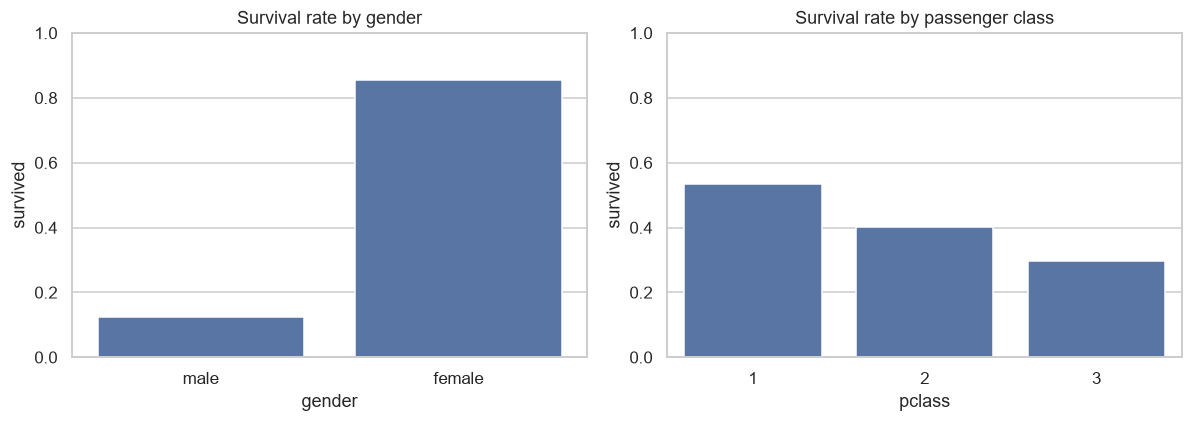

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=eda, x="gender", y="survived", errorbar=None, ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title("Survival rate by gender")
sns.barplot(data=eda, x="pclass", y="survived", errorbar=None, ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("Survival rate by passenger class")
plt.tight_layout()
plt.show()

여성 생존율 85.4%와 남성 12.3%의 차이가 큽니다. 1등급은 53.3%, 3등급은 29.8%입니다. 성별과 객실등급은 기본 피처로 유지할 근거가 있습니다.

In [13]:
# EDA 복사본에만 만듭니다. 원본 CSV는 변경하지 않습니다.
eda["FamilySize"] = eda["sibsp"] + eda["parch"] + 1
eda["IsAlone"] = (eda["FamilySize"] == 1).astype(int)
display(eda.groupby("FamilySize")[target_col].agg(["size", "mean"]))
display(eda.groupby("IsAlone")[target_col].agg(["size", "mean"]))

,size,mean
FamilySize,,
1,426,0.300469
2,115,0.565217
3,85,0.517647
4,21,0.714286
5,11,0.181818
6,15,0.133333
7,8,0.375000
8,3,0.000000
11,3,0.333333


,size,mean
IsAlone,,
0,261,0.505747
1,426,0.300469


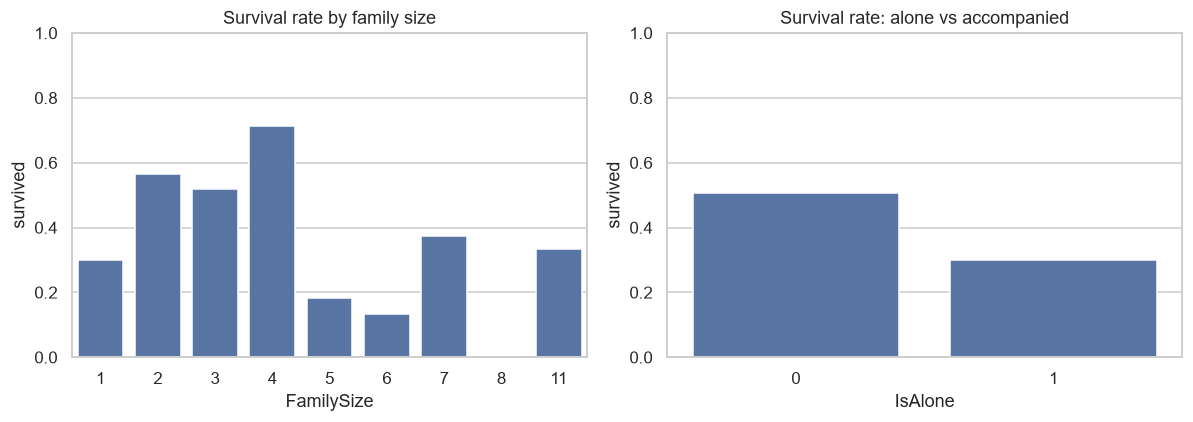

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=eda, x="FamilySize", y="survived", errorbar=None, ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title("Survival rate by family size")
sns.barplot(data=eda, x="IsAlone", y="survived", errorbar=None, ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("Survival rate: alone vs accompanied")
plt.tight_layout()
plt.show()

가족 규모별 생존율은 단순 직선 관계로 보기 어렵습니다. FamilySize와 IsAlone을 후보로 사용할 수 있지만, 대가족 범주는 표본이 적으므로 위 표의 size를 함께 봐야 합니다.

In [15]:
display(eda.groupby("embarked", dropna=False)[target_col].agg(["size", "mean"]))

,size,mean
embarked,,
C,134,0.462687
Q,62,0.516129
S,491,0.338086


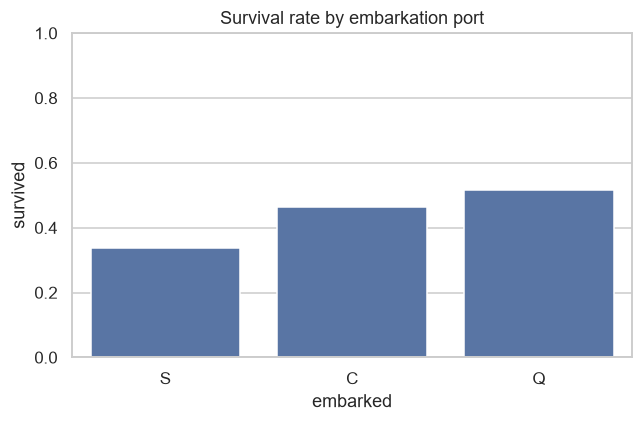

In [16]:
plt.figure(figsize=(6, 4))
sns.barplot(data=eda, x="embarked", y="survived", order=["S", "C", "Q"], errorbar=None)
plt.ylim(0, 1)
plt.title("Survival rate by embarkation port")
plt.tight_layout()
plt.show()

학습 부분에서 S 항구 생존율은 33.8%, C는 46.3%, Q는 51.6%입니다. 항구 차이는 등급·성별 구성 차이와 함께 해석해야 하며 항구 자체의 인과효과로 단정하지 않습니다.

In [17]:
display(eda.groupby(["gender", "survived"])["age"].agg(["count", "median"]))
display(eda.groupby(["pclass", "gender"])[target_col].agg(["size", "mean"]))

count  median
gender survived               
female 0            32    22.5
       1           170    26.5
male   0           312    28.0
       1            47    28.0

size      mean
pclass gender                
1      female    66  1.000000
       male      99  0.222222
2      female    59  0.932203
       male     100  0.090000
3      female   115  0.730435
       male     248  0.096774

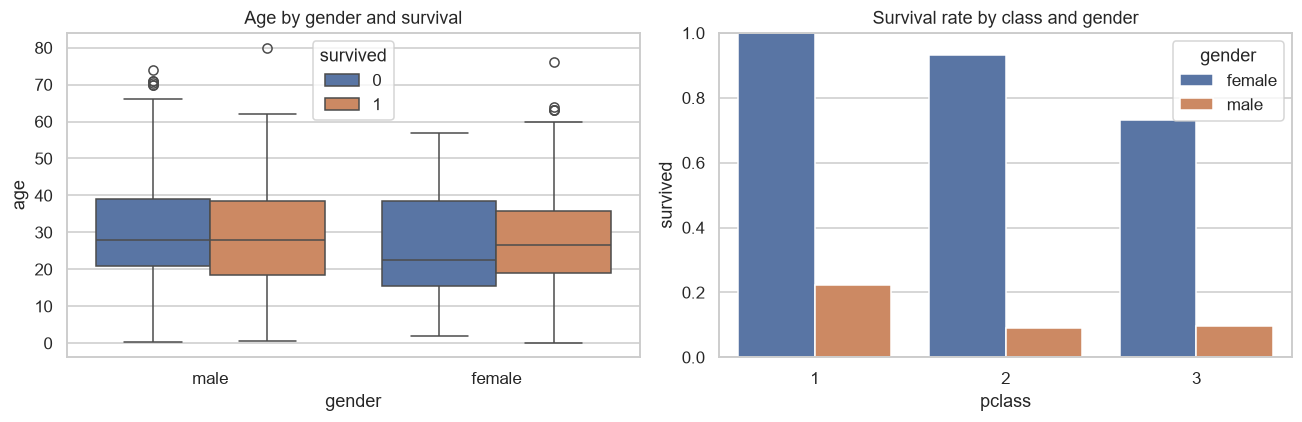

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=eda, x="gender", y="age", hue="survived", ax=axes[0])
axes[0].set_title("Age by gender and survival")
sns.barplot(data=eda, x="pclass", y="survived", hue="gender", errorbar=None, ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("Survival rate by class and gender")
plt.tight_layout()
plt.show()

성별을 나눈 뒤에도 연령 분포는 겹치므로 나이 하나로 생존을 설명하기 어렵습니다. 등급별 성별 생존율을 함께 확인해 gender×pclass 조합을 후보로 검토할 수 있습니다.

# 7. Features vs Features
운임·나이·등급·가족 규모를 함께 봅니다. 산점도 점 하나는 승객 한 명입니다.

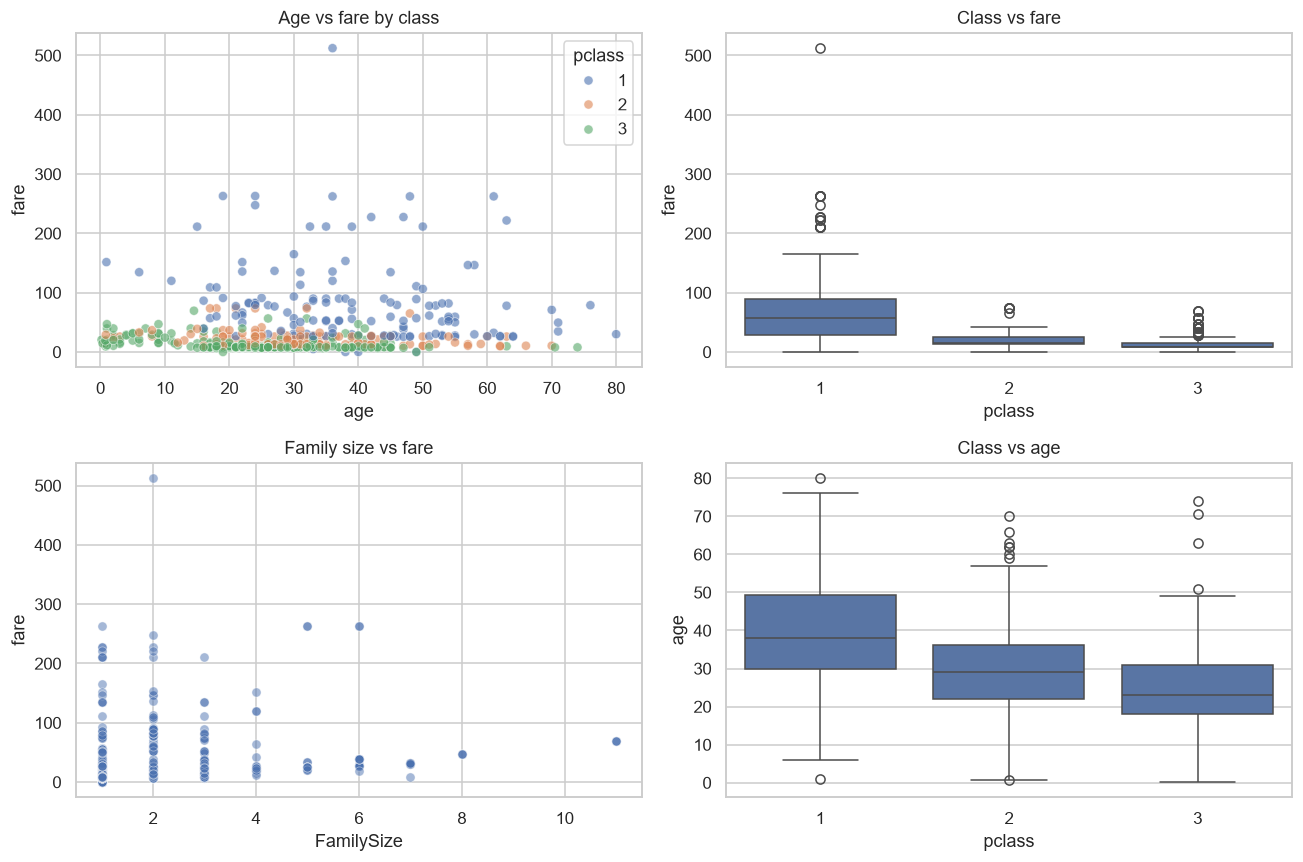

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.scatterplot(data=eda, x="age", y="fare", hue="pclass", palette="deep", alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title("Age vs fare by class")
sns.boxplot(data=eda, x="pclass", y="fare", ax=axes[0, 1])
axes[0, 1].set_title("Class vs fare")
sns.scatterplot(data=eda, x="FamilySize", y="fare", alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title("Family size vs fare")
sns.boxplot(data=eda, x="pclass", y="age", ax=axes[1, 1])
axes[1, 1].set_title("Class vs age")
plt.tight_layout()
plt.show()

1등급 쪽에 높은 운임이 집중되고, 객실등급에 따라 연령 분포도 다릅니다. 운임과 가족 규모의 관계는 Fare/FamilySize 후보를 검토할 근거지만, 가족 수와 실제 공동 티켓 인원이 같다는 보장은 없습니다.

# 8. 결측치 분석
전처리 판단은 학습 부분으로 합니다. test의 결측치는 적용 시 필요한 처리 항목을 확인하는 용도입니다.

In [20]:
missing_rate = eda.drop(columns=["FamilySize", "IsAlone"]).isna().mean() * 100
print("EDA 결측 개수")
print(eda.isna().sum())
print("전체 train 결측 개수")
print(train.isna().sum())
print("test 결측 개수")
print(test.isna().sum())

EDA 결측 개수
passengerid      0
survived         0
pclass           0
name             0
gender           0
age            126
sibsp            0
parch            0
ticket           0
fare             0
cabin          543
embarked         0
FamilySize       0
IsAlone          0
dtype: int64
전체 train 결측 개수
passengerid      0
survived         0
pclass           0
name             0
gender           0
age            180
sibsp            0
parch            0
ticket           0
fare             0
cabin          718
embarked         1
dtype: int64
test 결측 개수
passengerid      0
pclass           0
name             0
gender           0
age             83
sibsp            0
parch            0
ticket           0
fare             1
cabin          296
embarked         1
dtype: int64


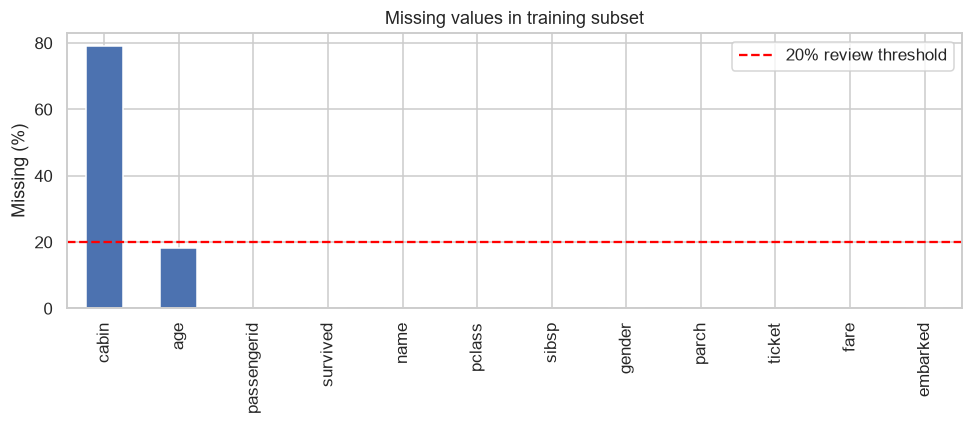

In [21]:
plt.figure(figsize=(9, 4))
missing_rate.sort_values(ascending=False).plot.bar()
plt.axhline(20, color="red", linestyle="--", label="20% review threshold")
plt.ylabel("Missing (%)")
plt.title("Missing values in training subset")
plt.legend()
plt.tight_layout()
plt.show()

cabin은 학습 부분의 약 79%가 결측으로 원본 객실번호 삭제를 고려합니다. age는 생존과 관련될 수 있어 20% 경계만으로 삭제하지 않고 성별·등급별 중앙값을 검토합니다. test의 fare/embarked 결측도 학습 통계로 채워야 합니다.

# 9. 상관관계 분석
ID는 제외합니다. 성별·항구 문자열에 Pearson 상관을 적용하지 않습니다. pclass는 등급을 숫자로 표현했다는 한계가 있습니다.

In [22]:
numeric_features = eda[["pclass", "age", "sibsp", "parch", "fare", "FamilySize"]]
correlation = numeric_features.corr()
display(correlation)
print("원본 수치형과 target의 상관")
print(eda[["pclass", "age", "sibsp", "parch", "fare", "survived"]].corr()["survived"])

,pclass,age,sibsp,parch,fare,FamilySize
pclass,1.000000,-0.430001,0.079037,0.071946,-0.557486,0.090183
age,-0.430001,1.000000,-0.237832,-0.214682,0.148668,-0.272218
sibsp,0.079037,-0.237832,1.000000,0.408164,0.158457,0.886410
parch,0.071946,-0.214682,0.408164,1.000000,0.185533,0.784387
fare,-0.557486,0.148668,0.158457,0.185533,1.000000,0.201739
FamilySize,0.090183,-0.272218,0.886410,0.784387,0.201739,1.000000


원본 수치형과 target의 상관
pclass     -0.199133
age        -0.054162
sibsp       0.018404
parch       0.096152
fare        0.173310
survived    1.000000
Name: survived, dtype: float64


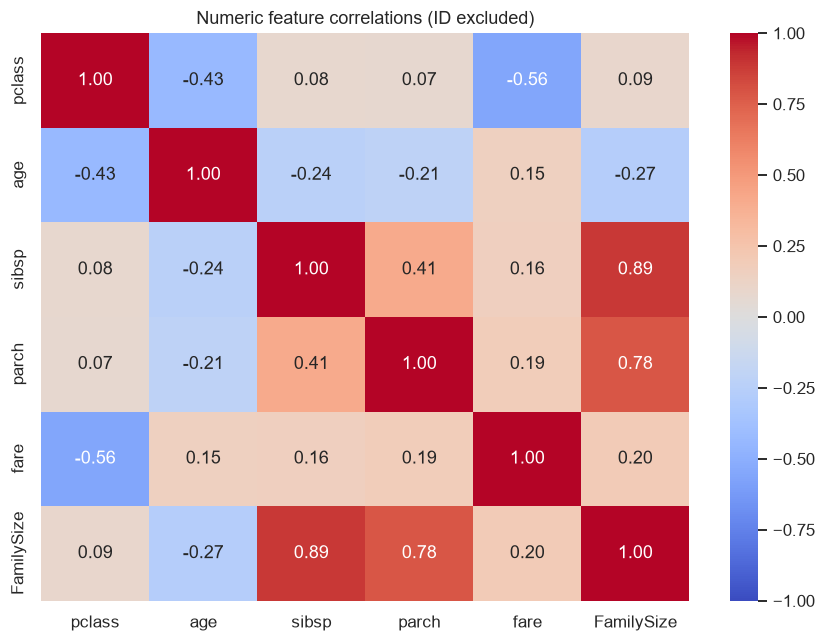

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Numeric feature correlations (ID excluded)")
plt.tight_layout()
plt.show()

원본 변수에서는 pclass–fare 상관이 -0.557, pclass–age는 -0.430입니다. FamilySize는 sibsp/parch의 합으로 만들어 상관이 높은 것이 자연스럽습니다. 같은 식인 family_size와 FamilySize를 동시에 만들 필요는 없습니다.

# 10. EDA 결과 정리
## EDA 결과 요약
1. **Target 비율:** 전체 train 생존 37.8%, 사망 62.2%. 학습 부분만 분석해 validation 분리를 유지했습니다.
2. **Target 관련 피처:** 성별 차이가 가장 두드러지며 객실등급·운임·항구별 차이도 관측됩니다. 인과관계는 아닙니다.
3. **상관 높은 조합:** 원본에서는 pclass–fare(-0.557), pclass–age(-0.430). FamilySize와 구성 변수는 정의상 겹칩니다.
4. **결측치:** 전체 train cabin 718개, age 180개, embarked 1개. 삭제/치환 기준을 학습 부분에서 결정해야 합니다.
5. **특이 분포:** fare는 오른쪽 꼬리가 길고 큰 값이 존재합니다. 값이 크다는 이유로 자동 삭제하지 않습니다.
6. **Feature Engineering 후보:** FamilySize·IsAlone, gender×pclass, log1p(fare), Fare/FamilySize. 후보를 한 번에 모두 추가하지 말고 validation AUC로 검증합니다.
7. **제거 고려:** ID는 학습 제외, 이름/티켓 원문은 고차원 문제 검토, cabin 원문은 높은 결측률 검토. 동일한 가족 크기 피처는 하나만 사용합니다.
8. **전처리:** 나이 그룹 중앙값과 전체 학습 중앙값 fallback, fare 중앙값, embarked 최빈값, 학습 기준 인코딩을 적용합니다. 여기서는 삭제·대체를 하지 않았습니다.

모델 학습과 제출 파일 생성은 `titanic_1.ipynb`에서 계속합니다. EDA 표본에서 발견한 관계가 새 데이터에서도 유지되는지는 검증이 필요합니다.